# GeoBench CaFFe

## Intro

CaFFe (Calving Fronts and where to Find them) [Gourmelon et al. 2022](https://doi.pangaea.de/10.1594/PANGAEA.940950) is a dataset designed for glacier calving front detection and land cover classification in polar regions. The dataset contains SAR (Synthetic Aperture Radar) imagery with corresponding zone masks that classify different surface types including glaciers, rock, ocean/ice melange, and undefined areas. This dataset is crucial for monitoring glacier retreat and calving dynamics in the context of climate change research.

## Dataset Characteristics

- **Modalities**: 
  - Sentinel-1 SAR imagery (single polarization)
- **Spatial Resolution**: Variable (typically 10-20m ground sample distance)
- **Temporal Resolution**: Single acquisition per location
- **Spectral Bands**: 
  - SAR: Single band grayscale intensity
- **Image Dimensions**: 512x512 pixels per patch
- **Labels**: 4 land cover classes (zone segmentation masks)
  - Class 0: N/A / Undefined
  - Class 1: Rock
  - Class 2: Glacier
  - Class 3: Ocean/Ice melange
- **Geographic Distribution**: Arctic and Antarctic regions (multiple glacier sites)
- **Temporal Coverage**: Various acquisition dates across multiple years


## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

The original dataset was released as a set of single channel gray scale PNG files of the underlying SAR imagery. Additionally, there is a metadata csv file from which geographic coordinates could be inferred. 

1. **Patch Generation**:
   - Image files 
   - Generated 512x512 pixel patches from original PNG images
   - Applied different overlap strategies per split (training: 0%, validation/test: 25%)
   - Calculated patch coordinates based on image bounds and metadata

2. **Split Generation**:
   - Used original train/test splits from source dataset
   - Created validation split by randomly sampling 10% from training data (random_state=1)
   - Applied geographic filtering: removed Southern Hemisphere samples from test set
3. **Dataset Subsampling**:
    - The final version consists of
        - 4,000 training samples
        - 1,000 validation samples
        - 2,000 test samples

### Label Processing
- **Zone Mask Remapping**: Converted original mask values to sequential class indices:
  - 0 → 0 (N/A)
  - 64 → 1 (Rock)
  - 127 → 2 (Glacier)
  - 254 → 3 (Ocean/Ice melange)

## References

1. Gourmelon, Nora; Seehaus, Thorsten; Braun, Matthias Holger; Maier, Andreas; Christlein, Vincent (2022): CaFFe (CAlving Fronts and where to Find thEm: a benchmark dataset and methodology for automatic glacier calving front extraction from sar imagery) [dataset]. PANGAEA, https://doi.org/10.1594/PANGAEA.940950

In [7]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchCaFFeDataModule
from geobench_v2.datasets import GeoBenchCaFFe
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
DATA_ROOT = Path("../../data/caffe")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "caffe_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "caffe_stats_clip_rescale.json")

In [9]:
band_order = GeoBenchCaFFe.band_default_order


datamodule = GeoBenchCaFFeDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


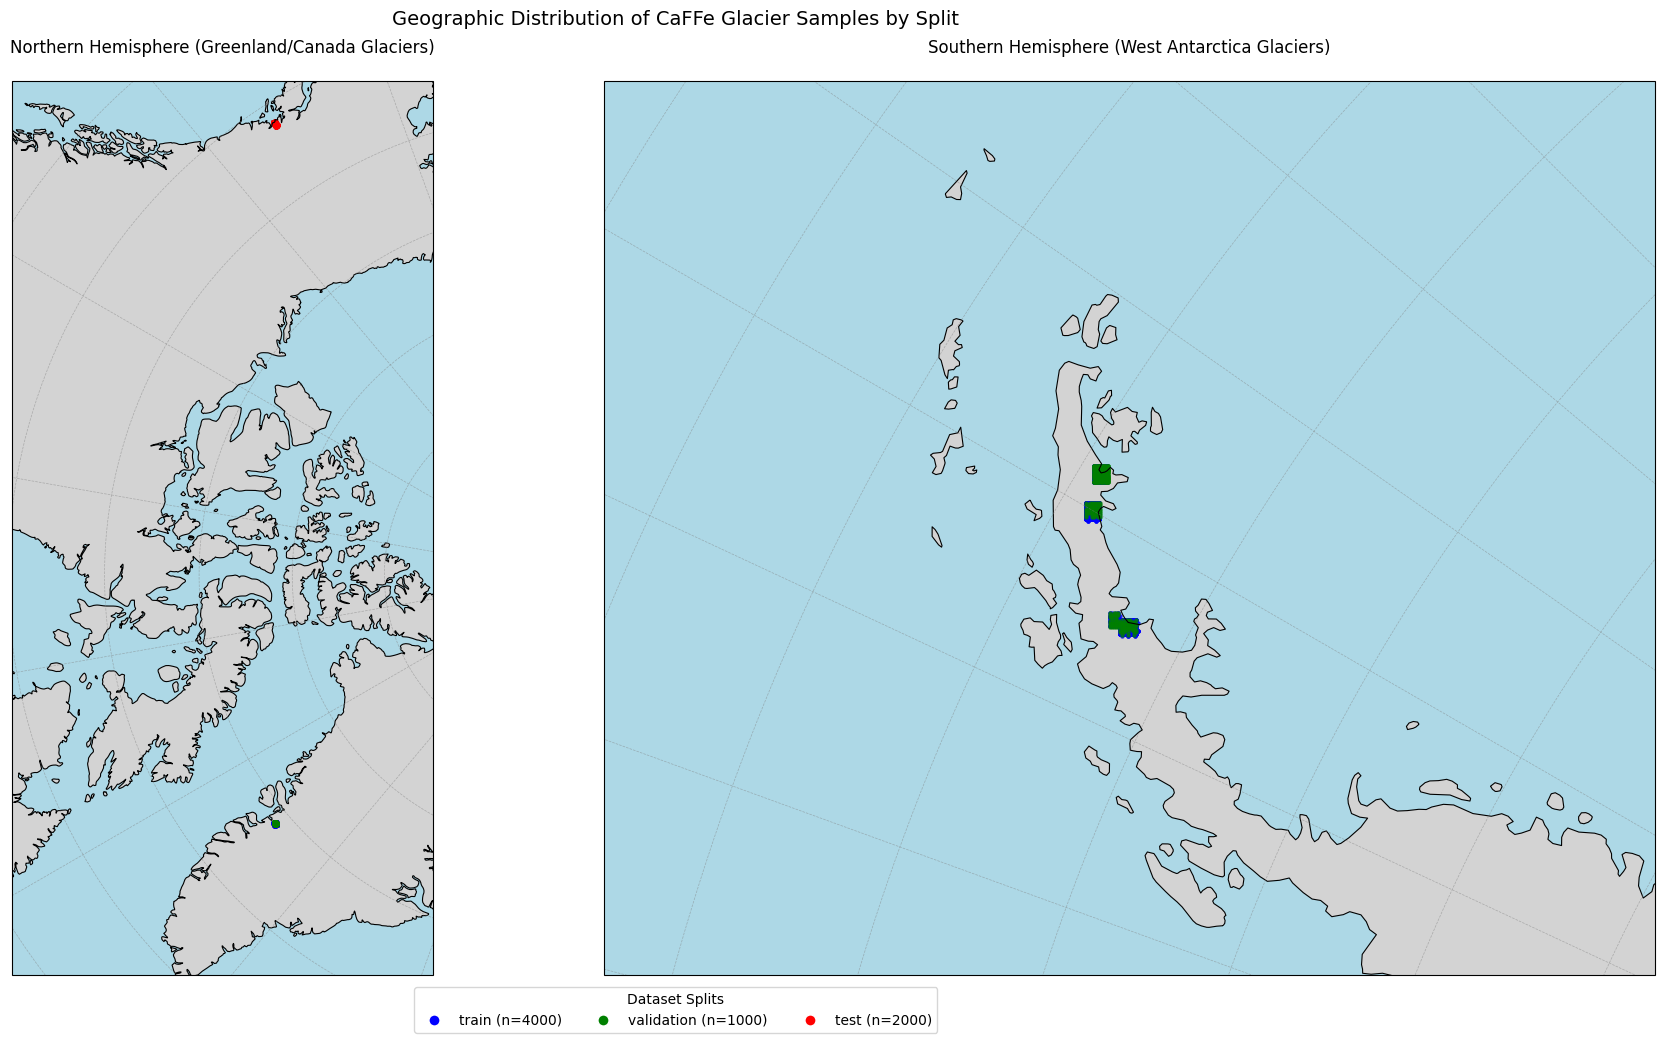

In [10]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Dataset Statistics

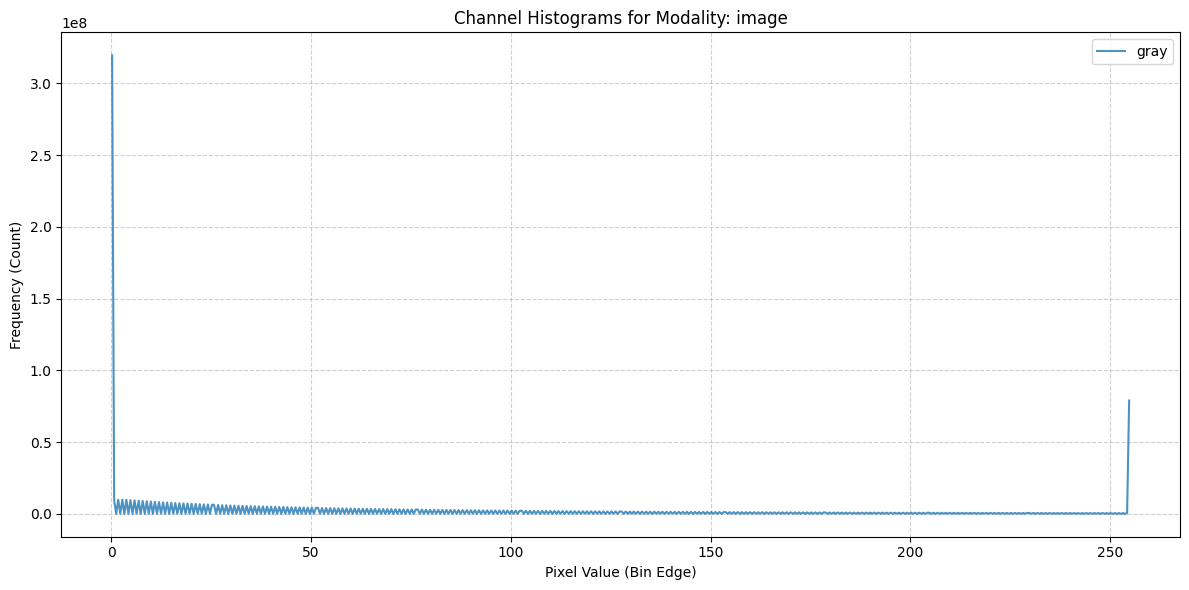

In [11]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

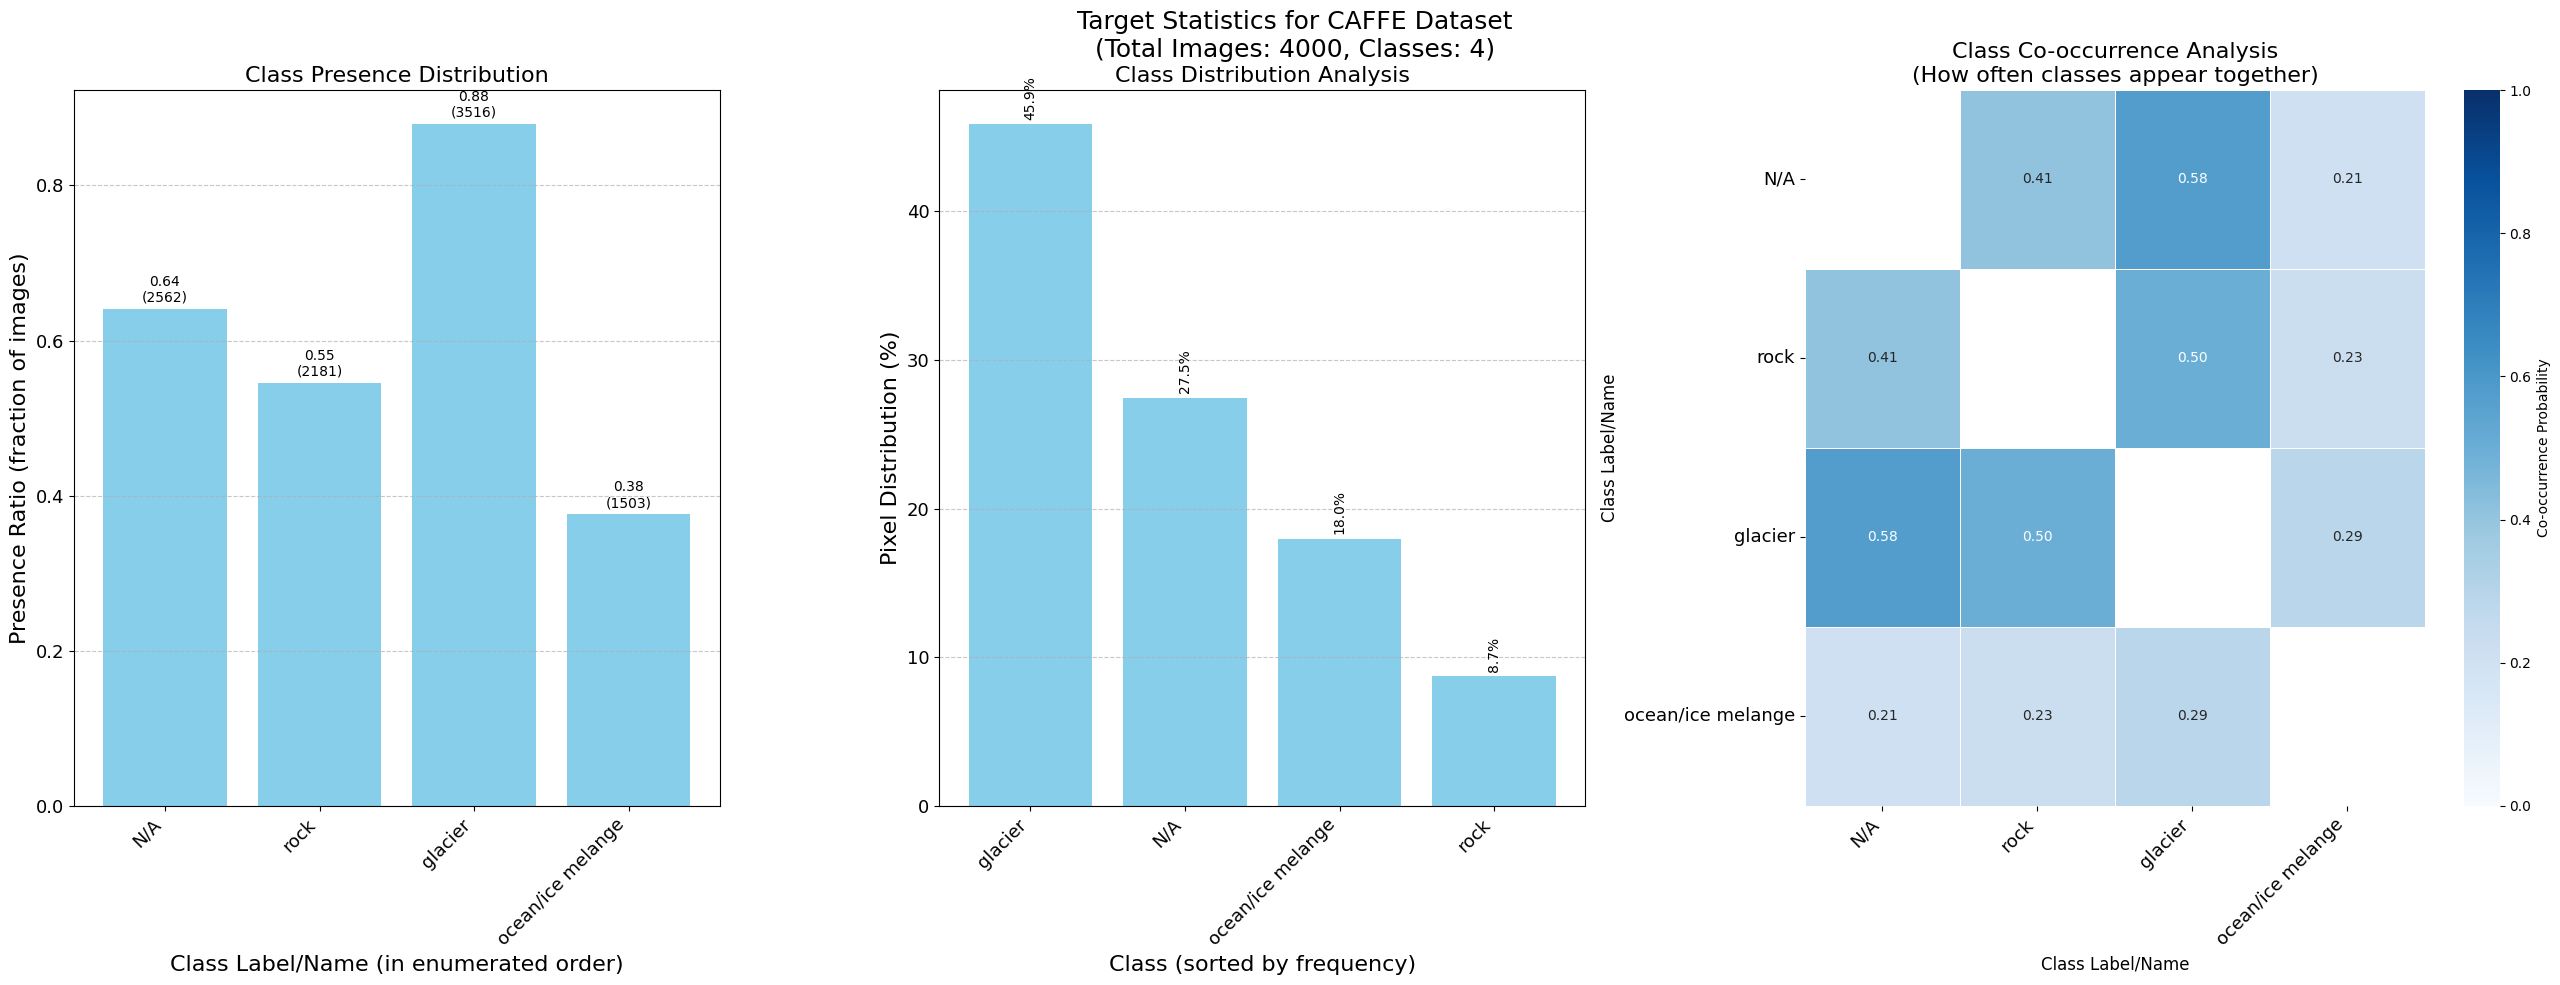

In [12]:
fig = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "CaFFe")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

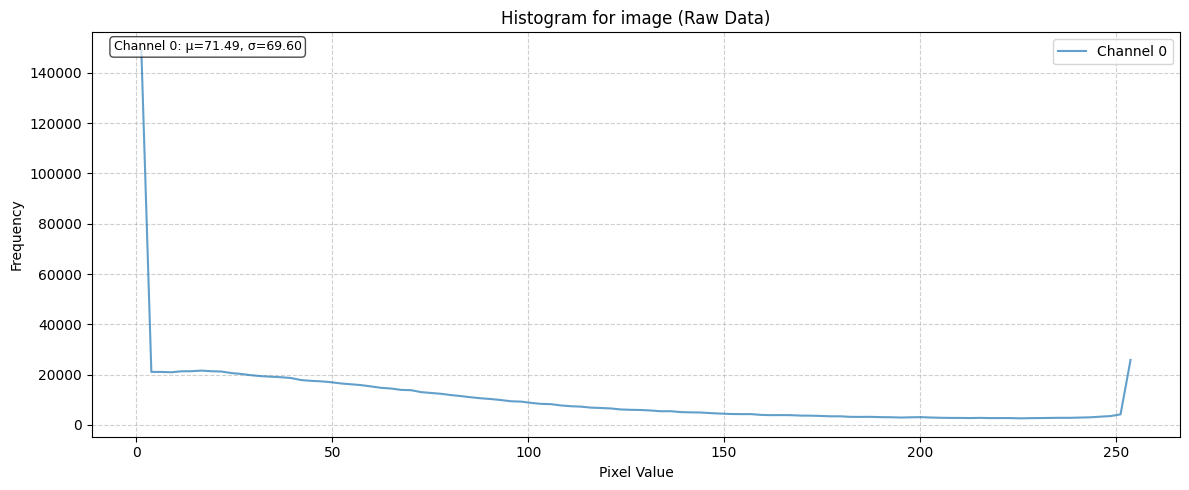

In [13]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

In [14]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

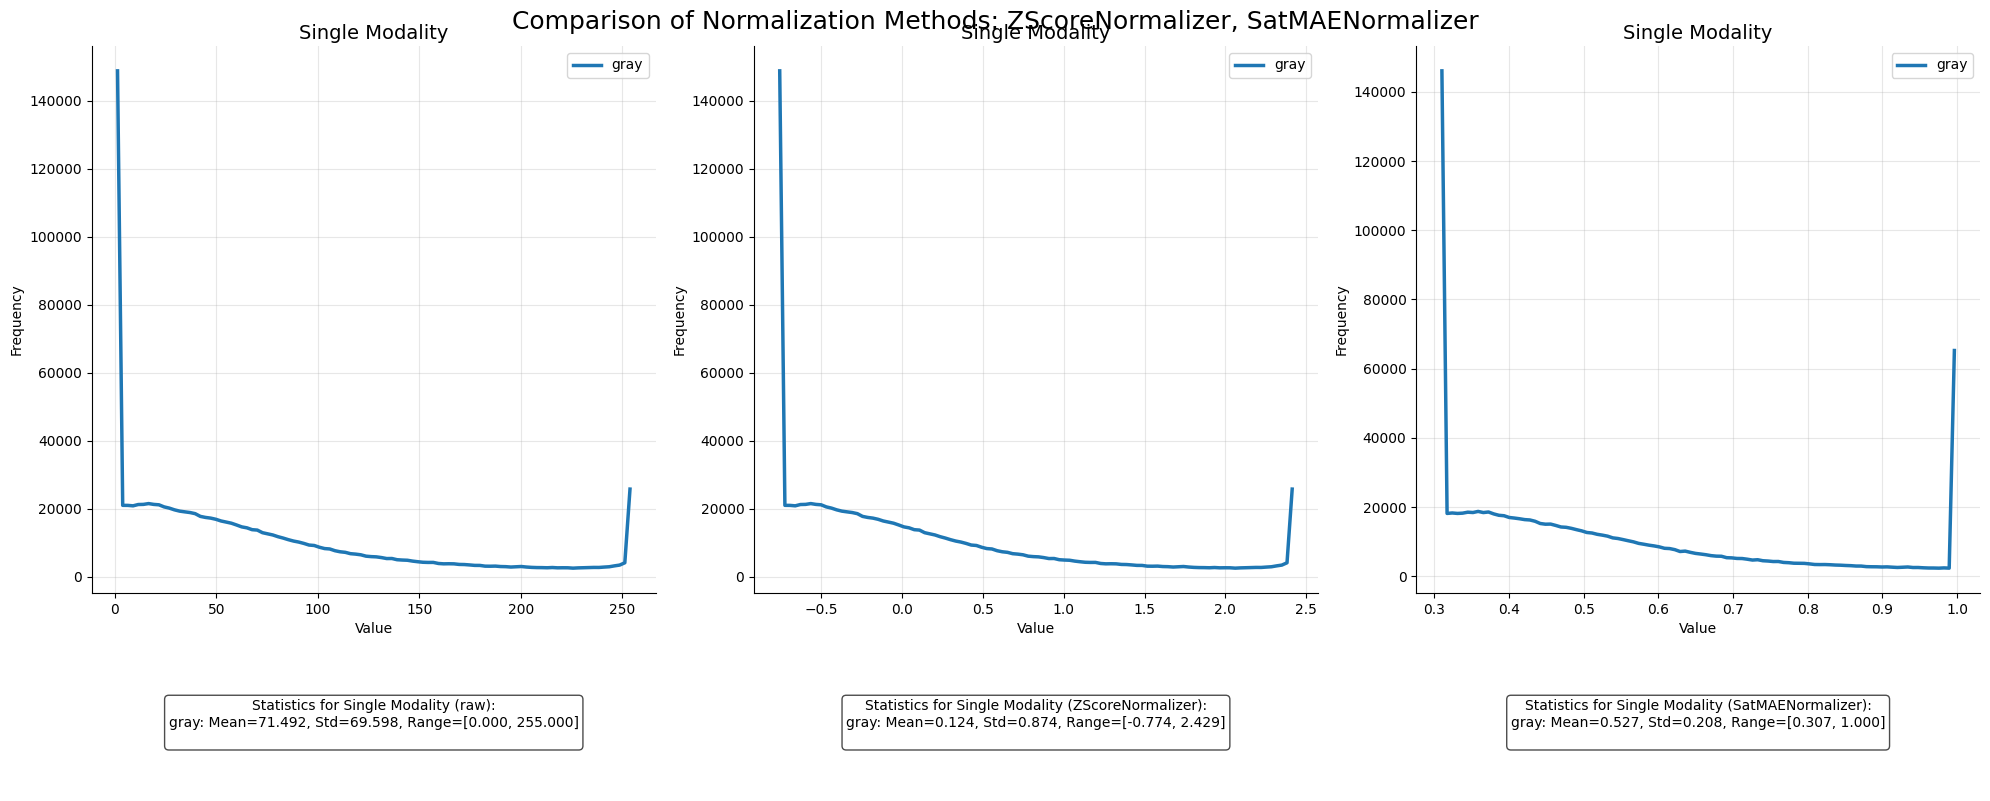

In [15]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

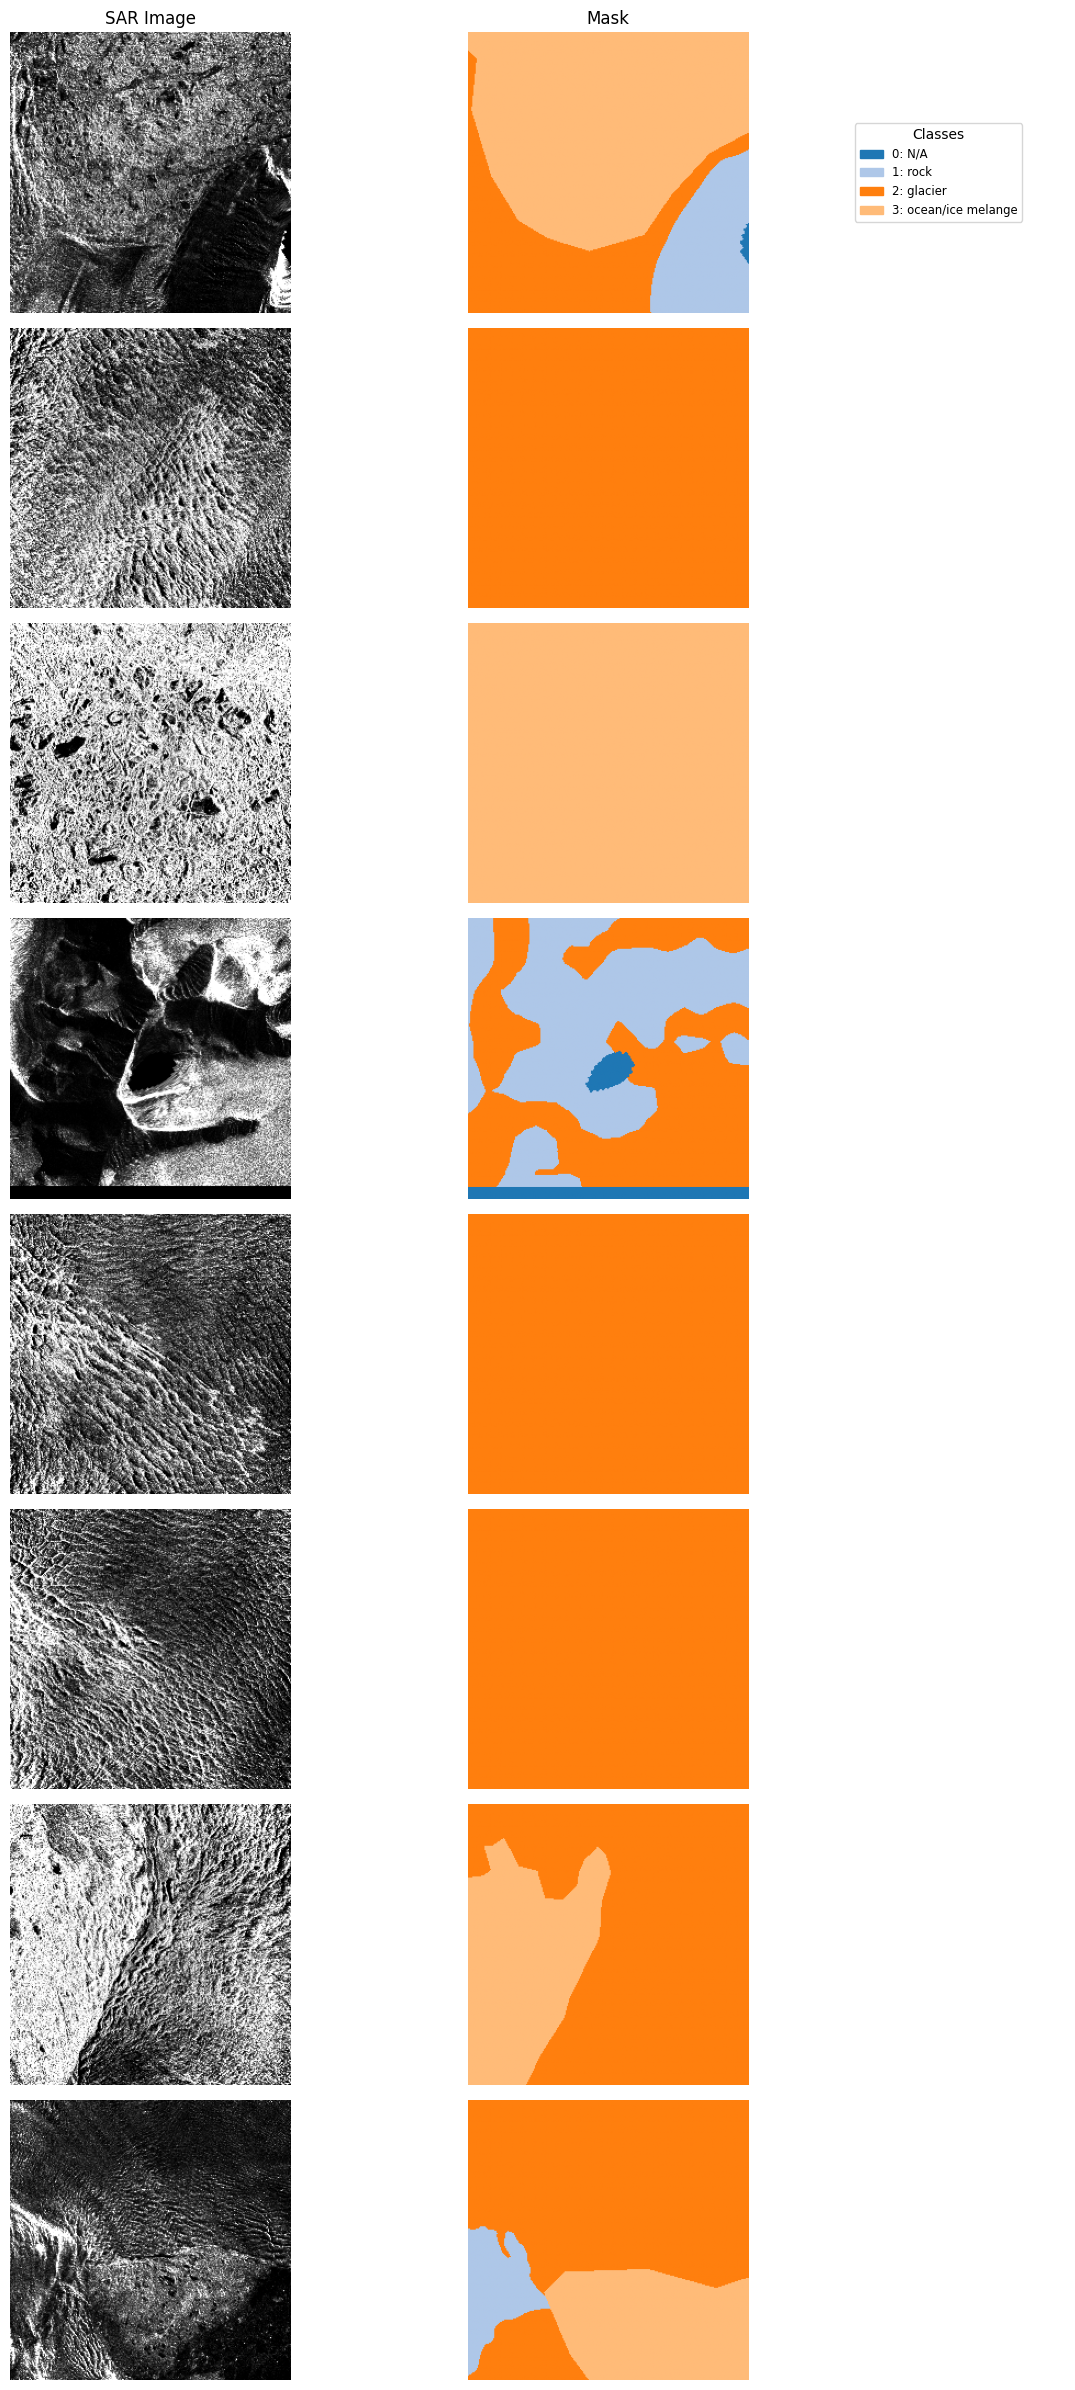

In [16]:
fig, batch = datamodule.visualize_batch()